In [10]:
#salary Dataset
#import libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv("Salary_dataset.csv")
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [11]:
#EDA

# Number of rows and columns
df.shape

(30, 3)

In [12]:
type(df)

pandas.core.frame.DataFrame

In [13]:
# Column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [14]:
# Summary statistics for numeric columns
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [20]:
#to check nulls
df.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [22]:
#to check duplicates

df.duplicated().sum()

0

In [24]:
#visualization

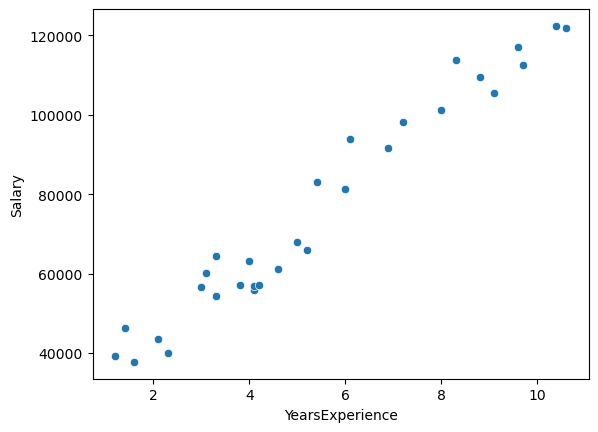

In [26]:
#scatterplot

sns.scatterplot(x='YearsExperience',y='Salary',data=df)
plt.show()

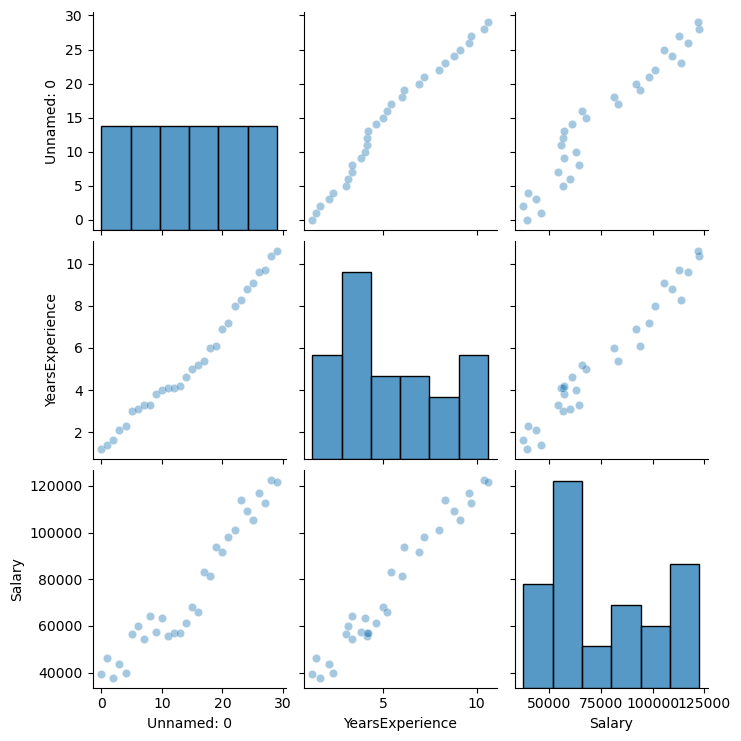

In [27]:
#pairplot

sns.pairplot(df,kind='scatter',plot_kws=dict(alpha=0.4))

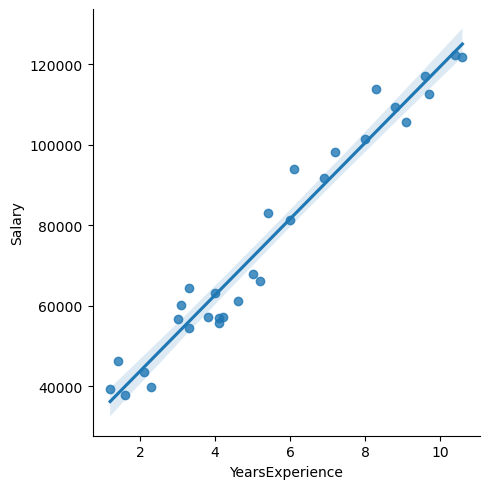

In [29]:
#linearmodel plot

sns.lmplot(df,x='YearsExperience',y='Salary')

In [30]:
#train_test_split

from sklearn.model_selection import train_test_split

In [31]:
x=df['YearsExperience']
y=df['Salary']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.3,        
    random_state=42      
)


In [38]:
#linear regression model

from sklearn.linear_model import LinearRegression


In [39]:
lm=LinearRegression()

In [42]:
# Convert X_train to a 2D array if it's a Series
if isinstance(X_train, pd.Series):
    X_train = X_train.to_frame()
    
# Now fit the model with the properly formatted data
lm.fit(X_train, y_train)

LinearRegression()

In [44]:
#predictions
if isinstance(X_test, pd.Series):
    X_test = X_test.to_frame()
    
y_pred=lm.predict(X_test)

In [46]:
print(y_pred)

[115574.62288352  71680.93878159 102499.90847018  75416.57147111
  55804.4998511   60474.04071301 122111.98009019 107169.44933209
  63275.76523015]


In [48]:
#evaluvate the model

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [50]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=mse**0.5
r2 = r2_score(y_test, y_pred)

In [52]:
print(mae,mse,rmse,r2)

5161.328710400178 37784662.46621308 6146.9230079945755 0.9414466227178215


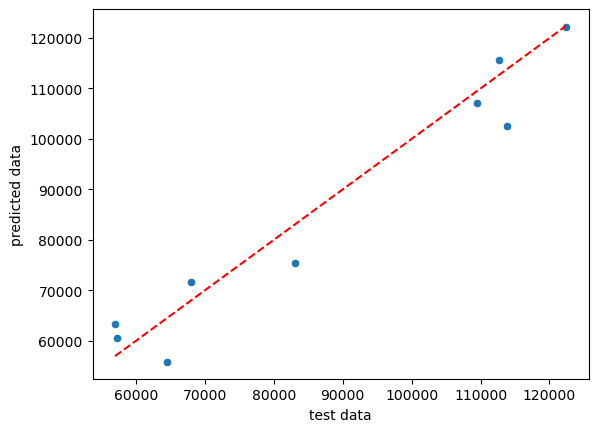

In [56]:
#visualization of actual vs predicted model

sns.scatterplot(x=y_test,y=y_pred)
plt.xlabel("test data")
plt.ylabel("predicted data")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # Perfect prediction line
plt.show()

In [58]:
#residual calculation

residual = y_test - y_pred
print(residual)

27    -2938.622884
15    -3741.938782
23    11313.091530
17     7672.428529
8      8641.500149
9     -3284.040713
28      280.019910
24     2262.550668
12    -6317.765230
Name: Salary, dtype: float64


In [66]:
#to save the model

import joblib 

In [70]:
joblib.dump(lm, 'linear_regression_model.joblib')
print("Model saved successfully")

Model saved successfully


In [72]:
loaded_model=joblib.load("linear_regression_model.joblib")
print("Model loaded successfully")

Model loaded successfully


In [78]:
# Convert Series to DataFrame if x is a Series
if isinstance(x, pd.Series):
    x = x.to_frame()
    
# Some models also expect y to be 2D

if isinstance(y, pd.Series):
 y = y.values.reshape(-1, 1)

test_score = loaded_model.score(x, y)
print(f"Model accuracy: {test_score:.4f}")

Model accuracy: 0.9565
